In [1]:
import yfinance as yf

samsung = yf.download("005930.KS", period="6mo")

samsung.columns = samsung.columns.get_level_values(0)

samsung.columns.name = None

samsung = samsung.reset_index()

samsung = samsung.rename(columns={"Date": "date"})

samsung.tail()

[*********************100%***********************]  1 of 1 completed


,date,Close,High,Low,Open,Volume
115,2026-06-16,343000.0,345500.0,332500.0,343000.0,17548685
116,2026-06-17,346500.0,348000.0,331500.0,332000.0,18134051
117,2026-06-18,362500.0,363000.0,344500.0,345000.0,32764450
118,2026-06-19,354000.0,374500.0,346250.0,372500.0,43284898
119,2026-06-22,353500.0,363000.0,342000.0,343000.0,26538632


In [2]:
samsung.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   date    120 non-null    datetime64[s]
 1   Close   120 non-null    float64      
 2   High    120 non-null    float64      
 3   Low     120 non-null    float64      
 4   Open    120 non-null    float64      
 5   Volume  120 non-null    int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 5.8 KB


In [3]:
samsung.describe()

,date,Close,High,Low,Open,Volume
count,120,120.000000,120.000000,120.000000,120.000000,1.200000e+02
mean,2026-03-23 10:36:00,212345.299479,216939.281590,206905.646040,211340.884342,3.013843e+07
min,2025-12-22 00:00:00,109738.304688,109738.304688,108546.576492,108943.819224,1.191000e+03
25%,2026-02-04 18:00:00,164609.289062,166929.480624,159844.157599,162937.751642,2.224235e+07
50%,2026-03-24 12:00:00,193299.742188,198439.267473,190854.961346,194846.709593,2.973285e+07
75%,2026-05-07 06:00:00,269000.000000,271750.000000,260000.000000,261000.000000,3.604513e+07
max,2026-06-22 00:00:00,362500.000000,374500.000000,348000.000000,372500.000000,8.942795e+07
std,NaN,66439.235252,68698.494496,63517.980796,65872.647471,1.093366e+07


In [4]:
samsung.isnull().sum()

date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

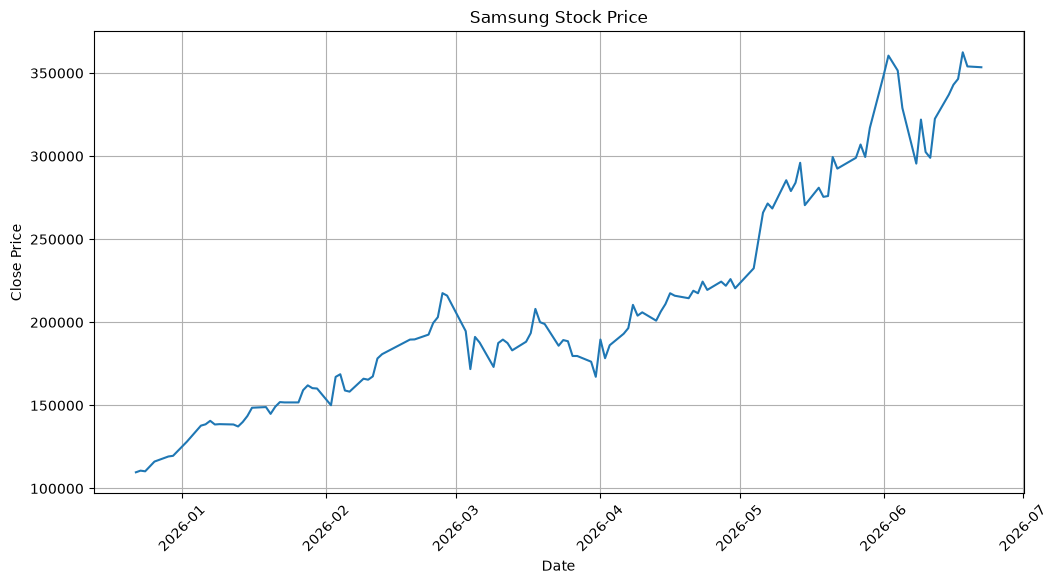

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(samsung["date"], samsung["Close"])

plt.title("Samsung Stock Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [6]:
samsung.to_csv(
    "../data/samsung_stock.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료!")

저장 완료!


In [7]:
samsung.tail()

,date,Close,High,Low,Open,Volume
115,2026-06-16,343000.0,345500.0,332500.0,343000.0,17548685
116,2026-06-17,346500.0,348000.0,331500.0,332000.0,18134051
117,2026-06-18,362500.0,363000.0,344500.0,345000.0,32764450
118,2026-06-19,354000.0,374500.0,346250.0,372500.0,43284898
119,2026-06-22,353500.0,363000.0,342000.0,343000.0,26538632


In [8]:
import pandas as pd

df = pd.read_csv("../data/samsung_stock.csv")

df.head()

,date,Close,High,Low,Open,Volume
0,2025-12-22,109738.304688,109738.304688,108546.576492,108943.819224,24859171
1,2025-12-23,110731.414062,111724.520915,109638.996525,110135.549951,20419187
2,2025-12-24,110334.164062,111625.202886,110135.542705,111625.202886,12492939
3,2025-12-26,116193.492188,116193.492188,111625.201042,111625.201042,34018174
4,2025-12-29,119253.171875,119452.758774,117955.857035,119153.378426,19676004


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    120 non-null    str    
 1   Close   120 non-null    float64
 2   High    120 non-null    float64
 3   Low     120 non-null    float64
 4   Open    120 non-null    float64
 5   Volume  120 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 5.8 KB


In [10]:
df.describe()

,Close,High,Low,Open,Volume
count,120.000000,120.000000,120.000000,120.000000,1.200000e+02
mean,212345.299479,216939.281590,206905.646040,211340.884342,3.013843e+07
std,66439.235252,68698.494496,63517.980796,65872.647471,1.093366e+07
min,109738.304688,109738.304688,108546.576492,108943.819224,1.191000e+03
25%,164609.289062,166929.480624,159844.157599,162937.751642,2.224235e+07
50%,193299.742188,198439.267473,190854.961346,194846.709593,2.973285e+07
75%,269000.000000,271750.000000,260000.000000,261000.000000,3.604513e+07
max,362500.000000,374500.000000,348000.000000,372500.000000,8.942795e+07


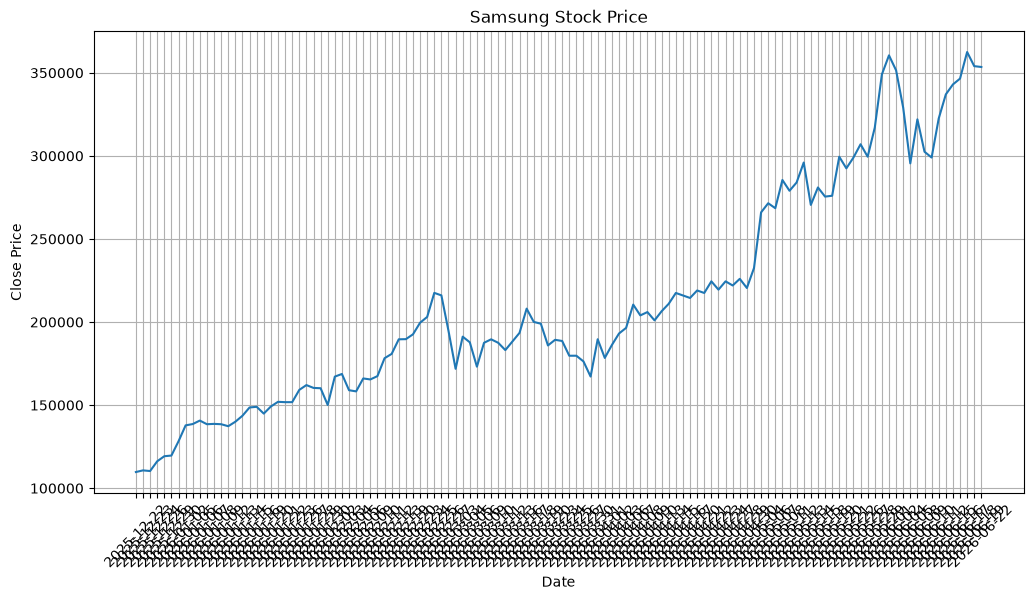

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(df["date"], df["Close"])

plt.title("Samsung Stock Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [12]:
df["return"] = df["Close"].pct_change() * 100

df[["date", "Close", "return"]].head()

,date,Close,return
0,2025-12-22,109738.304688,NaN
1,2025-12-23,110731.414062,0.904980
2,2025-12-24,110334.164062,-0.358751
3,2025-12-26,116193.492188,5.310529
4,2025-12-29,119253.171875,2.633263


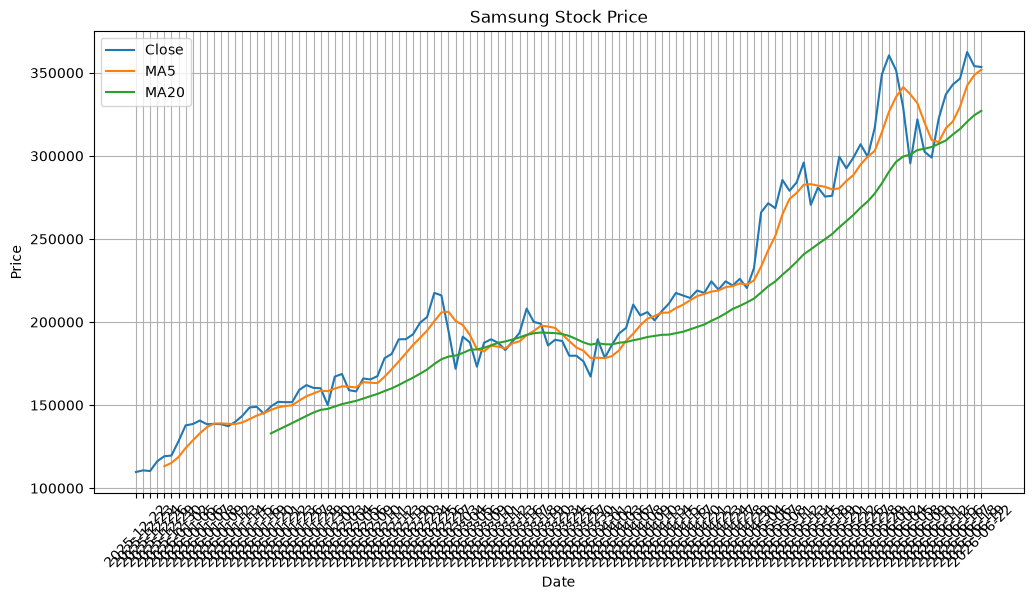

In [13]:
df["MA5"] = df["Close"].rolling(window=5).mean()
df["MA20"] = df["Close"].rolling(window=20).mean()

plt.figure(figsize=(12,6))

plt.plot(df["date"], df["Close"], label="Close")
plt.plot(df["date"], df["MA5"], label="MA5")
plt.plot(df["date"], df["MA20"], label="MA20")

plt.title("Samsung Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True)

plt.show()

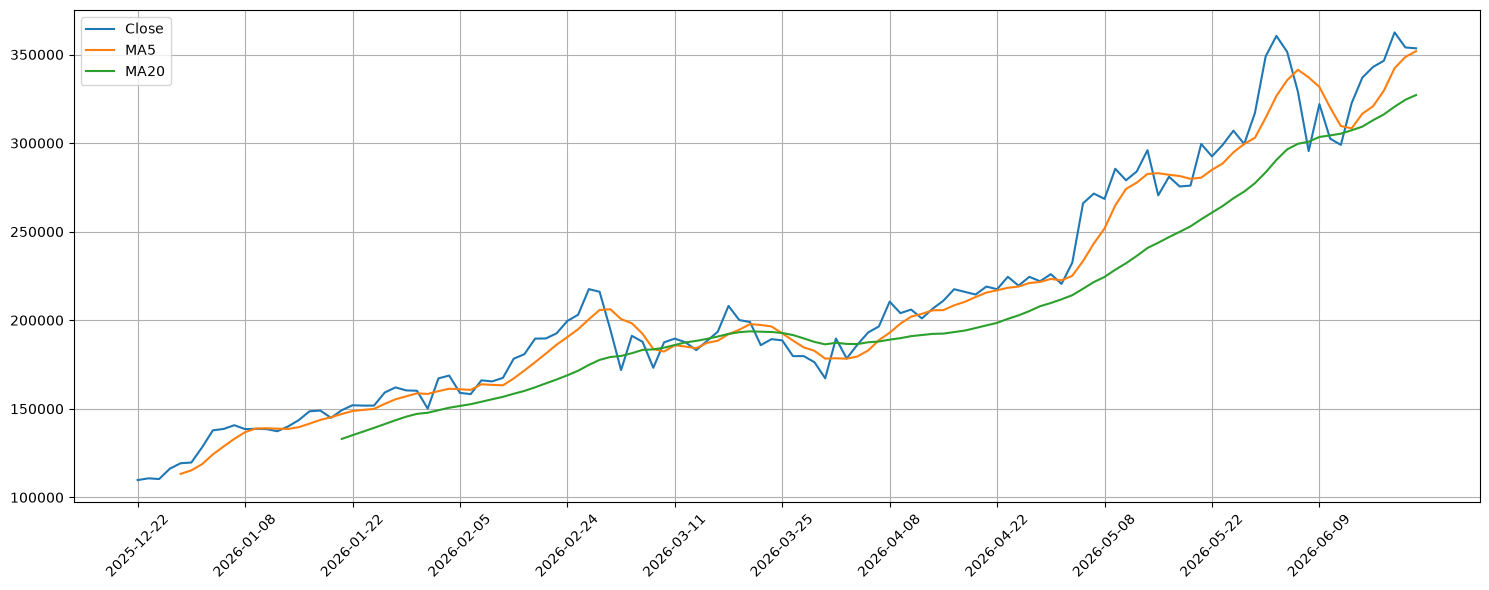

In [14]:
plt.figure(figsize=(15, 6))

plt.plot(df["date"], df["Close"], label="Close")
plt.plot(df["date"], df["MA5"], label="MA5")
plt.plot(df["date"], df["MA20"], label="MA20")

plt.legend()

plt.xticks(df["date"][::10], rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()